# Diabetic Retinopathy Detection using Fundus Images

This notebook trains and evaluates deep learning models for diabetic retinopathy severity classification using retinal fundus images.

Our Project Goals:

1. Load the APTOS 2019 Blindness Detection dataset.
2. Preprocess fundus images by cropping black borders, resizing, normalizing, and optionally enhancing contrast.
3. Handle class imbalance with class weights.
4. Train and compare multiple models:
   a. Baseline CNN
   b. ResNet50 transfer learning
   c. EfficientNetB0 transfer learning
5. Evaluate results with accuracy, precision, recall, F1 score, confusion matrix, and example predictions.
6. Include optional Grad-CAM visualizations for interpretability.

In [32]:
!pip install opencv-python
!pip install tensorflow numpy pandas matplotlib scikit-learn opencv-python seaborn tqdm


[notice] A new release of pip is available: 25.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ============================================
# 1. Imports and Configuration
# ============================================

import os
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# Project settings
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

# set to False
FAST_DEBUG = False

# Epochs
BASELINE_EPOCHS = 15
TRANSFER_EPOCHS_FROZEN = 10
TRANSFER_EPOCHS_FINE_TUNE = 10

if FAST_DEBUG:
    BASELINE_EPOCHS = 2
    TRANSFER_EPOCHS_FROZEN = 1
    TRANSFER_EPOCHS_FINE_TUNE = 1

CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}


TensorFlow version: 2.21.0
GPU devices: []


In [ ]:
# ============================================
# 2. Locate Dataset
# ============================================

# Kaggle path for APTOS 2019 Blindness Detection
KAGGLE_BASE = Path('/kaggle/input/aptos2019-blindness-detection')

if KAGGLE_BASE.exists():
    CSV_PATH = KAGGLE_BASE / 'train.csv'
    IMAGE_DIR = KAGGLE_BASE / 'train_images'
else:
    CSV_PATH = Path('train.csv')
    IMAGE_DIR = Path(".")

print("CSV path:", CSV_PATH)
print("Image directory:", IMAGE_DIR)

assert CSV_PATH.exists(), f"Could not find train.csv at {CSV_PATH}"
assert IMAGE_DIR.exists(), f"Could not find image directory at {IMAGE_DIR}"


CSV path: train.csv
Image directory: .


        id_code  diagnosis        image_path
0  000c1434d8d7          2  000c1434d8d7.png
1  001639a390f0          4  001639a390f0.png
2  0024cdab0c1e          1  0024cdab0c1e.png
3  002c21358ce6          0  002c21358ce6.png
4  005b95c28852          0  005b95c28852.png
Total images: 3662
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


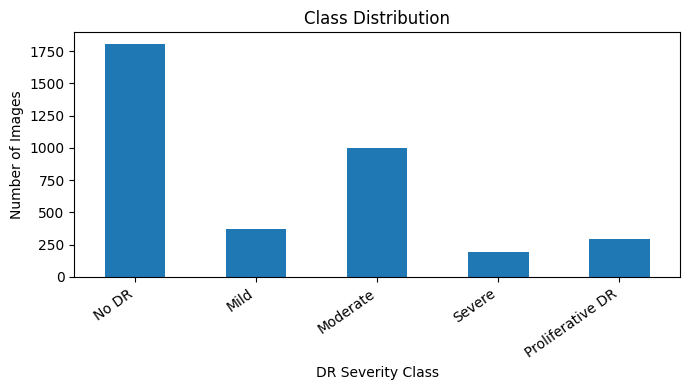

In [35]:
# ============================================
# 3. Load Labels and Inspect Class Distribution
# ============================================

df = pd.read_csv(CSV_PATH)

# APTOS train.csv contains columns: id_code, diagnosis
df['image_path'] = df['id_code'].apply(lambda image_id: str(IMAGE_DIR / f"{image_id}.png"))

print(df.head())
print("Total images:", len(df))
print(df['diagnosis'].value_counts().sort_index())

plt.figure(figsize=(7, 4))
df['diagnosis'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('DR Severity Class')
plt.ylabel('Number of Images')
plt.xticks(ticks=range(NUM_CLASSES), labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)], rotation=35, ha='right')
plt.tight_layout()
plt.show()

if FAST_DEBUG:
    # Keep class balance in debug mode by sampling from each class
    df = df.groupby('diagnosis', group_keys=False).apply(lambda group: group.sample(min(len(group), 80), random_state=SEED))
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    print("FAST_DEBUG dataset size:", len(df))


In [ ]:
# ============================================
# 4. Image Preprocessing Functions
# ============================================

# crops black borders from fundus images
def crop_black_borders(image, threshold=10):
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    mask = gray_image > threshold

    if not np.any(mask):
        return image

    coordinates = np.column_stack(np.where(mask))
    y_min, x_min = coordinates.min(axis=0)
    y_max, x_max = coordinates.max(axis=0)
    cropped = image[y_min:y_max + 1, x_min:x_max + 1]
    return cropped

# applies CLAHE contrast to the L channel in LAB color spaace
def enhance_contrast_clahe(image):
    lab_image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_l = clahe.apply(l_channel)
    enhanced_lab = cv2.merge((enhanced_l, a_channel, b_channel))
    enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    return enhanced_rgb

# reads, crops, enhances, and normalizes image
def load_and_preprocess_image(image_path, img_size=IMG_SIZE, use_crop=True, use_clahe=True):
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if use_crop:
        image = crop_black_borders(image)

    if use_clahe:
        image = enhance_contrast_clahe(image)

    image = cv2.resize(image, (img_size, img_size), interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32)
    return image


C:\Users\Ian\AppData\Local\Temp\ipykernel_9328\916265780.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby('diagnosis', group_keys=False).apply(lambda group: group.sample(1, random_state=SEED))


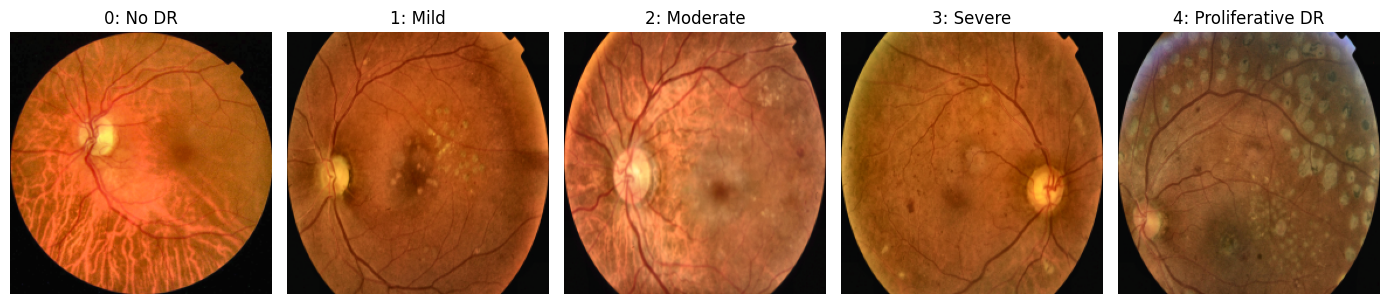

In [37]:
# ============================================
# 5. Visualize Preprocessed Images
# ============================================

sample_df = df.groupby('diagnosis', group_keys=False).apply(lambda group: group.sample(1, random_state=SEED))

plt.figure(figsize=(14, 6))
for plot_index, (_, row) in enumerate(sample_df.iterrows(), start=1):
    image = load_and_preprocess_image(row['image_path']) / 255.0
    plt.subplot(1, NUM_CLASSES, plot_index)
    plt.imshow(image)
    plt.title(f"{row['diagnosis']}: {CLASS_NAMES[row['diagnosis']]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [38]:
# ============================================
# 6. Train, Validation, and Test Split
# ============================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['diagnosis'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['diagnosis'],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(train_df['diagnosis'].value_counts().sort_index())


Train size: 2563
Validation size: 549
Test size: 550

Train distribution:
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64


In [39]:
# ============================================
# 7. Class Weights for Imbalanced Data
# ============================================

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(df['diagnosis'].unique())),
    y=train_df['diagnosis']
)

class_weights = {class_id: weight for class_id, weight in enumerate(class_weight_values)}
print("Class weights:")
print(class_weights)


Class weights:
{0: np.float64(0.4058590657165479), 1: np.float64(1.9791505791505792), 2: np.float64(0.7333333333333333), 3: np.float64(3.797037037037037), 4: np.float64(2.476328502415459)}


In [40]:
# ============================================
# 8. Data Generator
# ============================================

class FundusDataGenerator(Sequence):
    def __init__(self, dataframe, batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True, augment=False, model_type='baseline'):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.model_type = model_type
        self.indices = np.arange(len(self.dataframe))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, batch_index):
        batch_indices = self.indices[batch_index * self.batch_size:(batch_index + 1) * self.batch_size]
        batch_df = self.dataframe.iloc[batch_indices]

        images = []
        labels = []

        for _, row in batch_df.iterrows():
            image = load_and_preprocess_image(row['image_path'], img_size=self.img_size)

            if self.augment:
                image = self.apply_augmentation(image)

            image = self.apply_model_preprocessing(image)
            images.append(image)
            labels.append(row['diagnosis'])

        return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def apply_augmentation(self, image):
        # Random horizontal flip
        if np.random.rand() < 0.5:
            image = cv2.flip(image, 1)

        # Random rotation
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-20, 20)
            height, width = image.shape[:2]
            rotation_matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
            image = cv2.warpAffine(image, rotation_matrix, (width, height), borderMode=cv2.BORDER_REFLECT_101)

        # Random brightness and contrast
        if np.random.rand() < 0.5:
            alpha = np.random.uniform(0.85, 1.15)
            beta = np.random.uniform(-15, 15)
            image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

        return image.astype(np.float32)

    def apply_model_preprocessing(self, image):
        if self.model_type == 'resnet':
            return resnet_preprocess(image.copy())
        elif self.model_type == 'efficientnet':
            return efficientnet_preprocess(image.copy())
        else:
            return image / 255.0


In [41]:
# ============================================
# 9. Helper Functions for Training and Evaluation
# ============================================

def plot_training_history(history, title):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df['accuracy'], label='Train Accuracy')
    plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_df['loss'], label='Train Loss')
    plt.plot(history_df['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_predictions(model, generator):
    probabilities = model.predict(generator, verbose=1)
    predictions = np.argmax(probabilities, axis=1)
    true_labels = generator.dataframe['diagnosis'].values[:len(predictions)]
    return true_labels, predictions, probabilities

def evaluate_model(model, generator, model_name):
    true_labels, predictions, probabilities = get_predictions(model, generator)

    print(f"\nClassification Report for {model_name}")
    print(classification_report(
        true_labels,
        predictions,
        target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        zero_division=0
    ))

    cm = confusion_matrix(true_labels, predictions, labels=list(range(NUM_CLASSES)))
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
    fig, ax = plt.subplots(figsize=(9, 7))
    display.plot(ax=ax, xticks_rotation=35)
    plt.title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    accuracy = np.mean(true_labels == predictions)
    return {
        'model': model_name,
        'accuracy': accuracy,
        'true_labels': true_labels,
        'predictions': predictions,
        'probabilities': probabilities
    }

def make_callbacks(model_name):
    os.makedirs('models', exist_ok=True)
    return [
        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7),
        ModelCheckpoint(
            filepath=f'models/{model_name}.keras',
            monitor='val_loss',
            save_best_only=True
        )
    ]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 637s 8s/step - accuracy: 0.3028 - loss: 1.6188 - val_accuracy: 0.1002 - val_loss: 1.7842 - learning_rate: 1.0000e-04
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 607s 8s/step - accuracy: 0.4616 - loss: 1.4753 - val_accuracy: 0.1002 - val_loss: 2.1595 - learning_rate: 1.0000e-04
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 605s 7s/step - accuracy: 0.4955 - loss: 1.4097 - val_accuracy: 0.1002 - val_loss: 2.4204 - learning_rate: 1.0000e-04
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 608s 8s/step - accuracy: 0.5158 - loss: 1.3393 - val_accuracy: 0.1002 - val_loss: 2.2352 - learning_rate: 3.0000e-05
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 609s 8s/step - accuracy: 0.5240 - loss: 1.3339 - val_accuracy: 0.1002 - val_loss: 1.9566 - learning_rate: 3.0000e-05
Baseline training time: 51.28 minutes


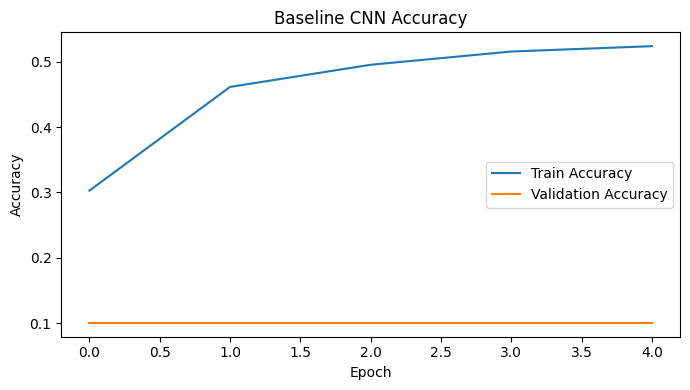

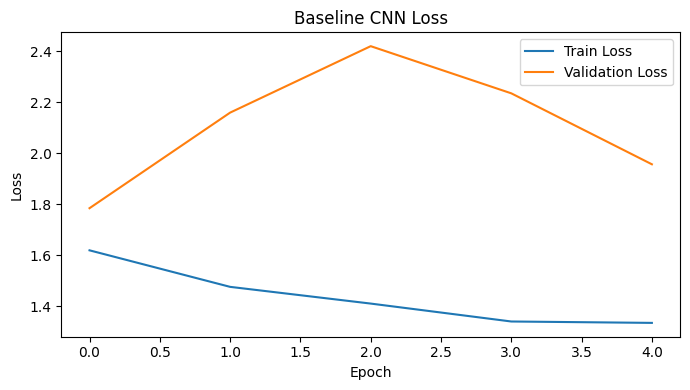

18/18 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step

Classification Report for Baseline CNN
                  precision    recall  f1-score   support

           No DR       0.00      0.00      0.00       271
            Mild       0.10      1.00      0.18        56
        Moderate       0.00      0.00      0.00       150
          Severe       0.00      0.00      0.00        29
Proliferative DR       0.00      0.00      0.00        44

        accuracy                           0.10       550
       macro avg       0.02      0.20      0.04       550
    weighted avg       0.01      0.10      0.02       550



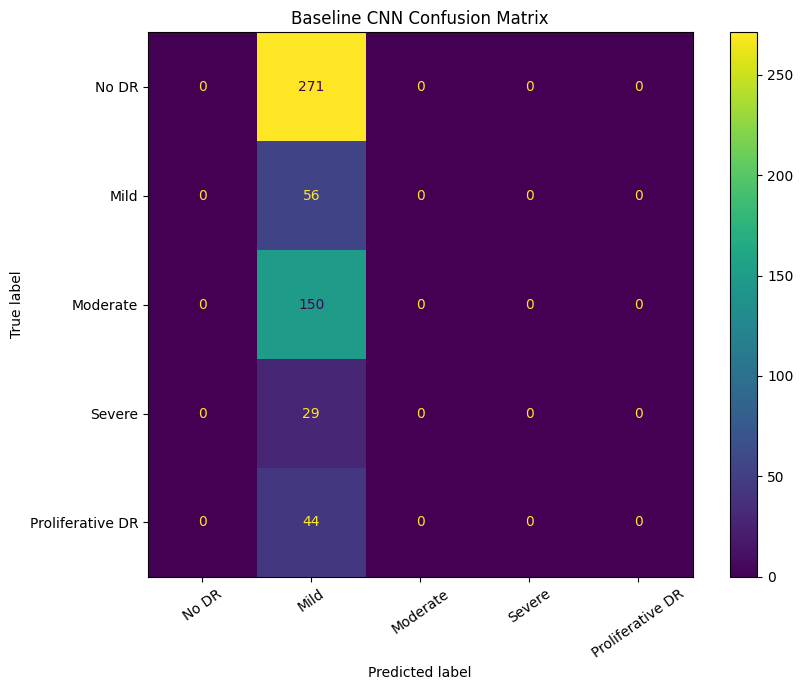

In [44]:
# ============================================
# 10. Baseline CNN
# ============================================

def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_train_gen = FundusDataGenerator(train_df, augment=True, model_type='baseline')
baseline_val_gen = FundusDataGenerator(val_df, shuffle=False, augment=False, model_type='baseline')
baseline_test_gen = FundusDataGenerator(test_df, shuffle=False, augment=False, model_type='baseline')

baseline_model = build_baseline_cnn()
baseline_model.summary()

start_time = time.time()
baseline_history = baseline_model.fit(
    baseline_train_gen,
    validation_data=baseline_val_gen,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=make_callbacks('baseline_cnn'),
    verbose=1
)
baseline_training_minutes = (time.time() - start_time) / 60
print(f"Baseline training time: {baseline_training_minutes:.2f} minutes")

plot_training_history(baseline_history, 'Baseline CNN')
baseline_results = evaluate_model(baseline_model, baseline_test_gen, 'Baseline CNN')


In [ ]:
# ============================================
# 11. Transfer Learning Model Builder
# ============================================

def build_transfer_model(base_model_name, input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    if base_model_name == 'resnet50':
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    elif base_model_name == 'efficientnetb0':
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    else:
        raise ValueError("base_model_name must be 'resnet50' or 'efficientnetb0'")

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

def fine_tune_model(model, base_model, trainable_layers=30, learning_rate=1e-5):
    base_model.trainable = True

    # Freeze most layers and only fine tune the last layers
    for layer in base_model.layers[:-trainable_layers]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,565 (91.99 MB)

 Trainable params: 526,341 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

c:\Users\Ian\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 610s 7s/step - accuracy: 0.3453 - loss: 2.0045 - val_accuracy: 0.6284 - val_loss: 0.9705 - learning_rate: 1.0000e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.4940 - loss: 1.6281 - val_accuracy: 0.6321 - val_loss: 0.9095 - learning_rate: 1.0000e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 594s 7s/step - accuracy: 0.5564 - loss: 1.4144 - val_accuracy: 0.5865 - val_loss: 0.9970 - learning_rate: 1.0000e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 595s 7s/step - accuracy: 0.5575 - loss: 1.4084 - val_accuracy: 0.6339 - val_loss: 0.9131 - learning_rate: 1.0000e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 601s 7s/step - accuracy: 0.5778 - loss: 1.3378 - val_accuracy: 0.6412 - val_loss: 0.8769 - learning_rate: 3.0000e-05
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5954 - loss: 1.2618 - val_accuracy: 0.6466 - val_loss: 0.8614 - learning_rate: 3.0000e-05
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5868 

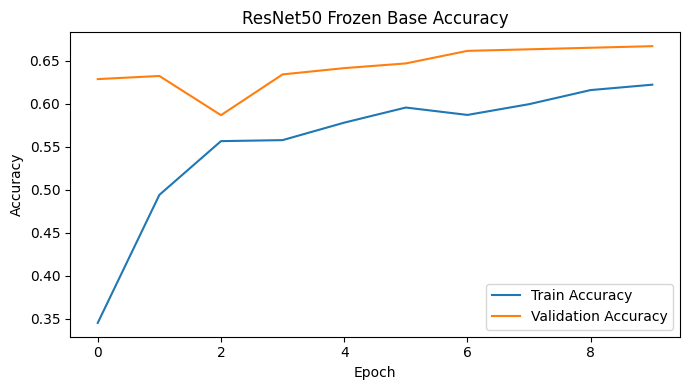

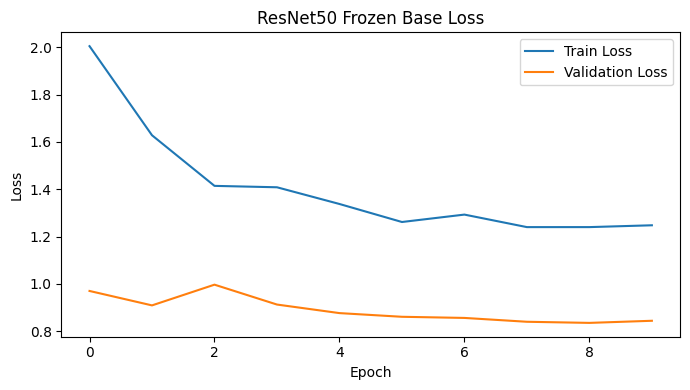

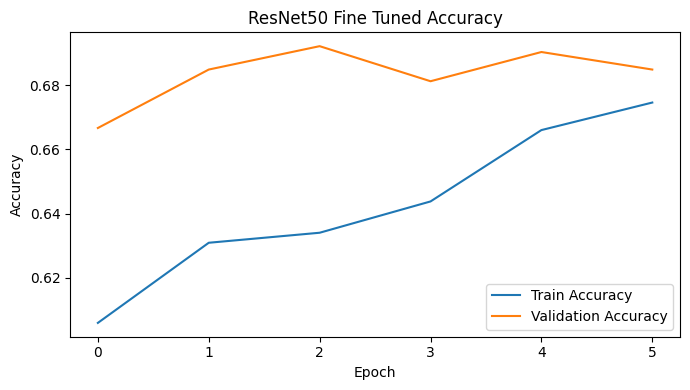

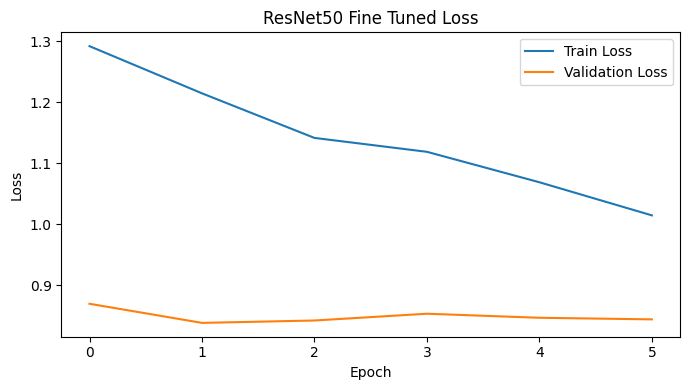

18/18 ━━━━━━━━━━━━━━━━━━━━ 105s 6s/step

Classification Report for ResNet50
                  precision    recall  f1-score   support

           No DR       0.95      0.94      0.95       271
            Mild       0.40      0.46      0.43        56
        Moderate       0.65      0.36      0.46       150
          Severe       0.19      0.48      0.27        29
Proliferative DR       0.35      0.45      0.40        44

        accuracy                           0.67       550
       macro avg       0.51      0.54      0.50       550
    weighted avg       0.72      0.67      0.68       550



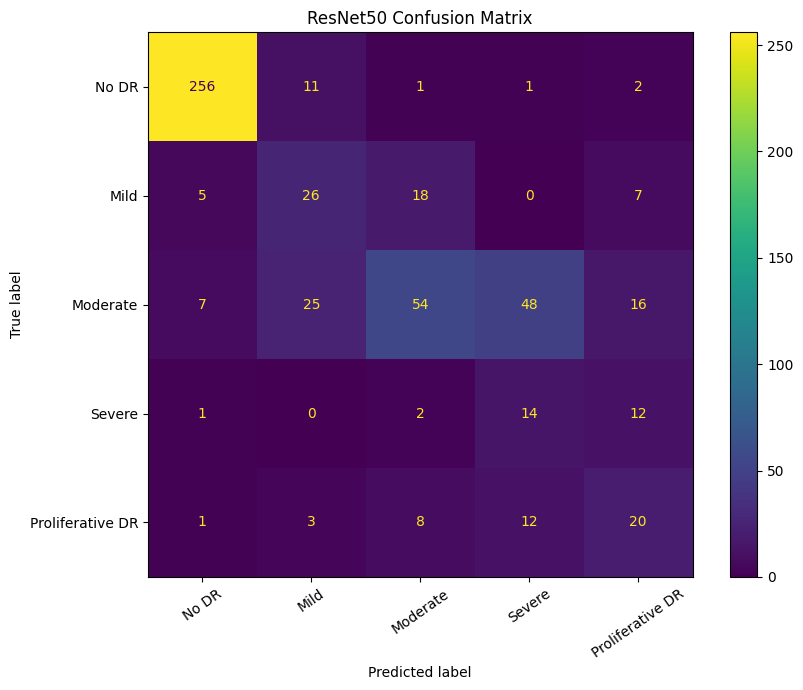

In [ ]:
# ============================================
# 12. ResNet50 Training
# ============================================

resnet_train_gen = FundusDataGenerator(train_df, augment=True, model_type='resnet')
resnet_val_gen = FundusDataGenerator(val_df, shuffle=False, augment=False, model_type='resnet')
resnet_test_gen = FundusDataGenerator(test_df, shuffle=False, augment=False, model_type='resnet')

resnet_model, resnet_base = build_transfer_model('resnet50')
resnet_model.summary()

start_time = time.time()
resnet_history_frozen = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=TRANSFER_EPOCHS_FROZEN,
    class_weight=class_weights,
    callbacks=make_callbacks('resnet50_frozen'),
    verbose=1
)

resnet_model = fine_tune_model(resnet_model, resnet_base, trainable_layers=30, learning_rate=1e-5)
resnet_history_finetune = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=TRANSFER_EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=make_callbacks('resnet50_finetuned'),
    verbose=1
)
resnet_training_minutes = (time.time() - start_time) / 60
print(f"ResNet50 total training time: {resnet_training_minutes:.2f} minutes")

plot_training_history(resnet_history_frozen, 'ResNet50 Frozen Base')
plot_training_history(resnet_history_finetune, 'ResNet50 Fine Tuned')
resnet_results = evaluate_model(resnet_model, resnet_test_gen, 'ResNet50')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,816 (16.71 MB)

 Trainable params: 329,733 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

c:\Users\Ian\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 581s 7s/step - accuracy: 0.2899 - loss: 2.1505 - val_accuracy: 0.6393 - val_loss: 1.0805 - learning_rate: 1.0000e-04
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 569s 7s/step - accuracy: 0.4105 - loss: 1.7775 - val_accuracy: 0.6230 - val_loss: 0.9793 - learning_rate: 1.0000e-04
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 618s 8s/step - accuracy: 0.4717 - loss: 1.5832 - val_accuracy: 0.5701 - val_loss: 0.9894 - learning_rate: 1.0000e-04
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 564s 7s/step - accuracy: 0.5201 - loss: 1.4888 - val_accuracy: 0.5811 - val_loss: 0.9689 - learning_rate: 1.0000e-04
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.5505 - loss: 1.4044 - val_accuracy: 0.5956 - val_loss: 0.9851 - learning_rate: 1.0000e-04
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 565s 7s/step - accuracy: 0.5618 - loss: 1.3445 - val_accuracy: 0.5974 - val_loss: 0.9778 - learning_rate: 1.0000e-04
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 563s 7s/step - accuracy: 0.5720 

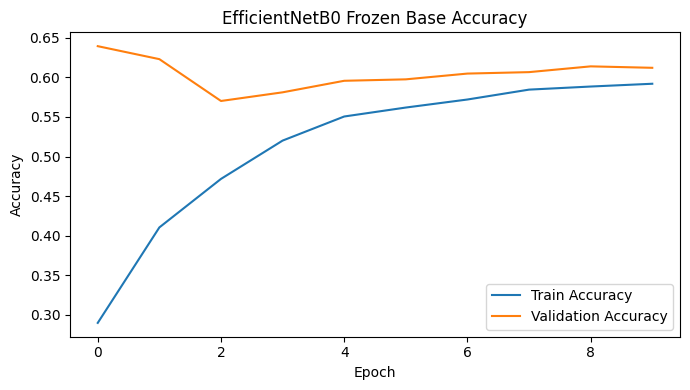

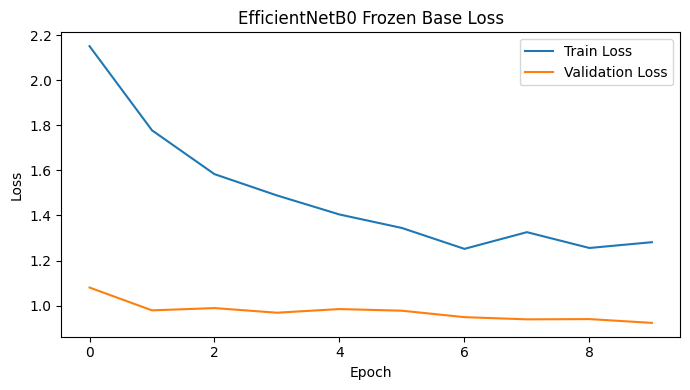

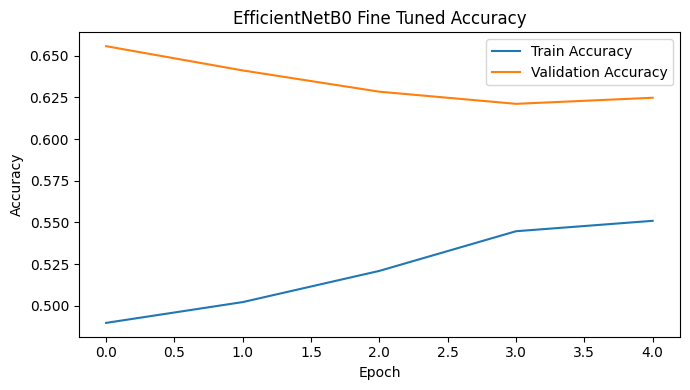

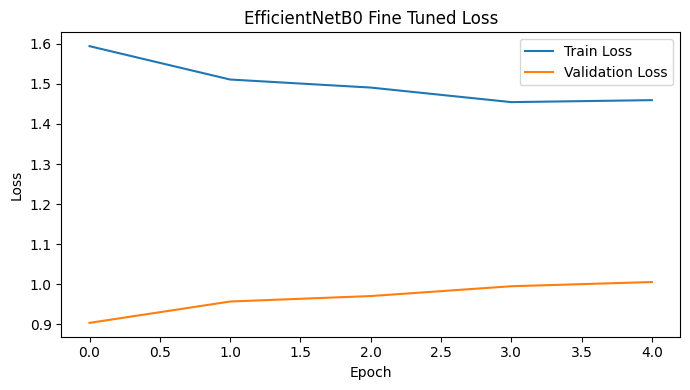

18/18 ━━━━━━━━━━━━━━━━━━━━ 98s 5s/step

Classification Report for EfficientNetB0
                  precision    recall  f1-score   support

           No DR       0.96      0.96      0.96       271
            Mild       0.39      0.57      0.46        56
        Moderate       0.76      0.25      0.38       150
          Severe       0.27      0.48      0.35        29
Proliferative DR       0.26      0.57      0.36        44

        accuracy                           0.67       550
       macro avg       0.53      0.57      0.50       550
    weighted avg       0.76      0.67      0.67       550



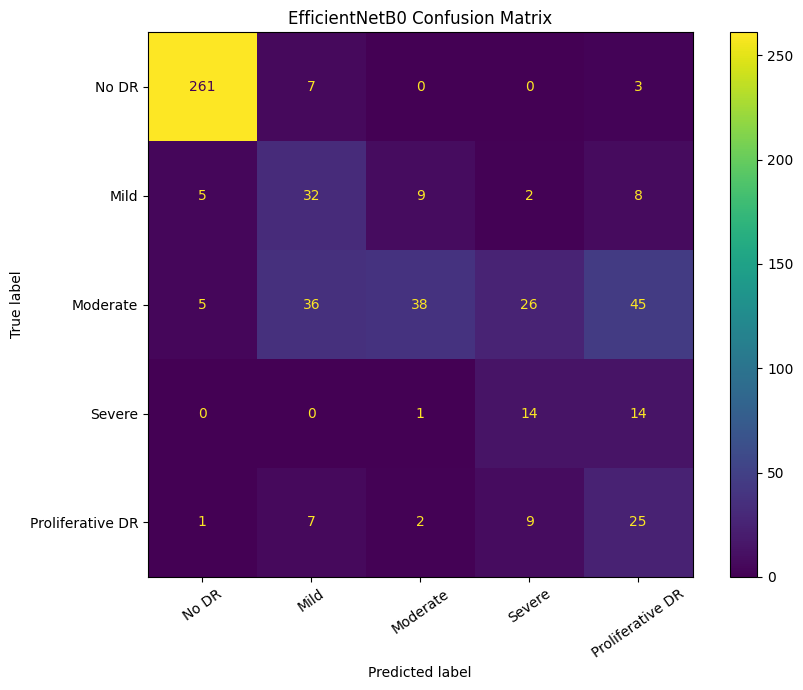

In [ ]:
# ============================================
# 13. EfficientNetB0 Training
# ============================================

efficientnet_train_gen = FundusDataGenerator(train_df, augment=True, model_type='efficientnet')
efficientnet_val_gen = FundusDataGenerator(val_df, shuffle=False, augment=False, model_type='efficientnet')
efficientnet_test_gen = FundusDataGenerator(test_df, shuffle=False, augment=False, model_type='efficientnet')

efficientnet_model, efficientnet_base = build_transfer_model('efficientnetb0')
efficientnet_model.summary()

start_time = time.time()
efficientnet_history_frozen = efficientnet_model.fit(
    efficientnet_train_gen,
    validation_data=efficientnet_val_gen,
    epochs=TRANSFER_EPOCHS_FROZEN,
    class_weight=class_weights,
    callbacks=make_callbacks('efficientnetb0_frozen'),
    verbose=1
)

efficientnet_model = fine_tune_model(efficientnet_model, efficientnet_base, trainable_layers=30, learning_rate=1e-5)
efficientnet_history_finetune = efficientnet_model.fit(
    efficientnet_train_gen,
    validation_data=efficientnet_val_gen,
    epochs=TRANSFER_EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=make_callbacks('efficientnetb0_finetuned'),
    verbose=1
)
efficientnet_training_minutes = (time.time() - start_time) / 60
print(f"EfficientNetB0 total training time: {efficientnet_training_minutes:.2f} minutes")

plot_training_history(efficientnet_history_frozen, 'EfficientNetB0 Frozen Base')
plot_training_history(efficientnet_history_finetune, 'EfficientNetB0 Fine Tuned')
efficientnet_results = evaluate_model(efficientnet_model, efficientnet_test_gen, 'EfficientNetB0')


            Model  Test Accuracy  Training Time Minutes
0    Baseline CNN       0.101818              51.684532
1        ResNet50       0.672727             162.542815
2  EfficientNetB0       0.672727             143.795469


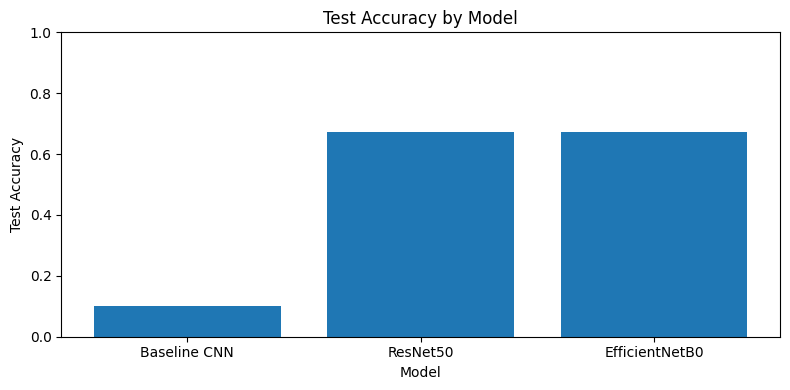

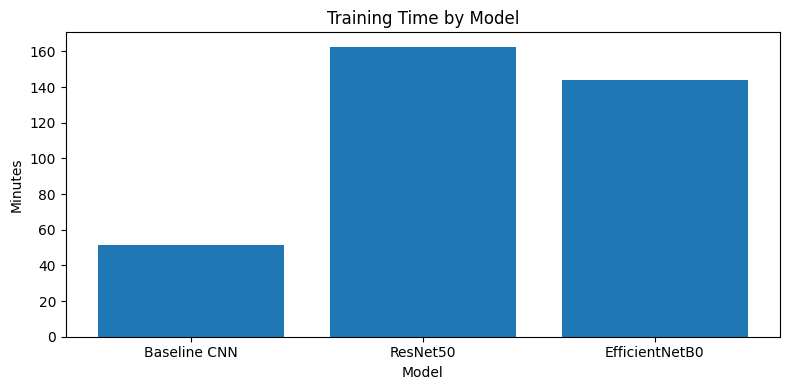

In [ ]:
# ============================================
# 14. Compare Model Results
# ============================================

results_summary = pd.DataFrame([
    {'Model': 'Baseline CNN', 'Test Accuracy': baseline_results['accuracy'], 'Training Time Minutes': baseline_training_minutes},
    {'Model': 'ResNet50', 'Test Accuracy': resnet_results['accuracy'], 'Training Time Minutes': resnet_training_minutes},
    {'Model': 'EfficientNetB0', 'Test Accuracy': efficientnet_results['accuracy'], 'Training Time Minutes': efficientnet_training_minutes}
])

print(results_summary)

plt.figure(figsize=(8, 4))
plt.bar(results_summary['Model'], results_summary['Test Accuracy'])
plt.title('Test Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_summary['Model'], results_summary['Training Time Minutes'])
plt.title('Training Time by Model')
plt.xlabel('Model')
plt.ylabel('Minutes')
plt.tight_layout()
plt.show()


Best model: ResNet50
18/18 ━━━━━━━━━━━━━━━━━━━━ 102s 6s/step


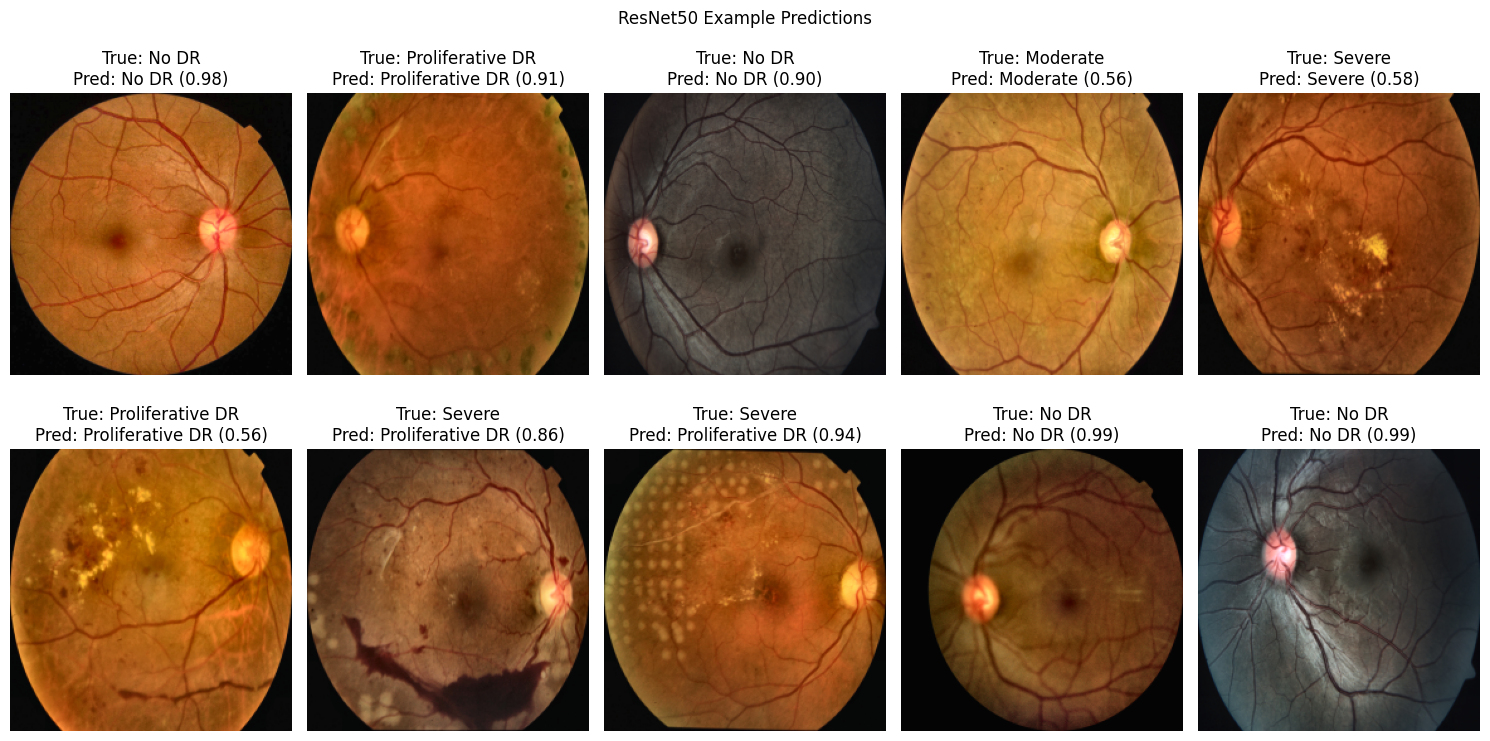

In [ ]:
# ============================================
# 15. Example Predictions
# ============================================

def show_example_predictions(model, generator, model_name, count=10):
    true_labels, predictions, probabilities = get_predictions(model, generator)
    sample_indices = np.random.choice(len(generator.dataframe), size=min(count, len(generator.dataframe)), replace=False)

    plt.figure(figsize=(15, 8))
    for plot_index, sample_index in enumerate(sample_indices, start=1):
        row = generator.dataframe.iloc[sample_index]
        image = load_and_preprocess_image(row['image_path']) / 255.0
        true_label = true_labels[sample_index]
        predicted_label = predictions[sample_index]
        confidence = probabilities[sample_index][predicted_label]

        plt.subplot(2, 5, plot_index)
        plt.imshow(image)
        plt.title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[predicted_label]} ({confidence:.2f})")
        plt.axis('off')

    plt.suptitle(f'{model_name} Example Predictions')
    plt.tight_layout()
    plt.show()

# Use the best model based on test accuracy
best_model_name = results_summary.sort_values('Test Accuracy', ascending=False).iloc[0]['Model']
print("Best model:", best_model_name)

if best_model_name == 'Baseline CNN':
    show_example_predictions(baseline_model, baseline_test_gen, 'Baseline CNN')
elif best_model_name == 'ResNet50':
    show_example_predictions(resnet_model, resnet_test_gen, 'ResNet50')
else:
    show_example_predictions(efficientnet_model, efficientnet_test_gen, 'EfficientNetB0')


In [ ]:
# ============================================
# 16. Optional Grad-CAM for Interpretability
# ============================================

def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
        if hasattr(layer, 'layers'):
            for nested_layer in reversed(layer.layers):
                if isinstance(nested_layer, tf.keras.layers.Conv2D):
                    return nested_layer.name
    raise ValueError('No convolutional layer found.')

def make_gradcam_heatmap(image_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(original_image, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(original_image.astype(np.uint8), 1 - alpha, heatmap, alpha, 0)
    return superimposed

# Grad-CAM is easiest with the baseline CNN because its convolutional layers are directly accessible.
try:
    gradcam_model = baseline_model
    last_conv_layer = find_last_conv_layer_name(gradcam_model)
    print("Last conv layer:", last_conv_layer)

    row = test_df.sample(1, random_state=SEED).iloc[0]
    original_image = load_and_preprocess_image(row['image_path'])
    model_input = np.expand_dims(original_image / 255.0, axis=0)

    heatmap = make_gradcam_heatmap(model_input, gradcam_model, last_conv_layer)
    gradcam_image = display_gradcam(original_image, heatmap)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image.astype(np.uint8))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gradcam_image)
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
except Exception as error:
    print("Grad-CAM skipped:", error)


Last conv layer: conv2d_3
Grad-CAM skipped: The layer sequential has never been called and thus has no defined output.


In [ ]:
# ============================================
# 17. Save Final Results
# ============================================

os.makedirs('results', exist_ok=True)
results_summary.to_csv('results/model_comparison_summary.csv', index=False)

baseline_model.save('results/baseline_cnn_final.keras')
resnet_model.save('results/resnet50_final.keras')
efficientnet_model.save('results/efficientnetb0_final.keras')

print("Saved results to the results/ folder.")
print(results_summary)


Saved results to the results/ folder.
            Model  Test Accuracy  Training Time Minutes
0    Baseline CNN       0.101818              51.684532
1        ResNet50       0.672727             162.542815
2  EfficientNetB0       0.672727             143.795469
